In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("vegemite.csv")

In [40]:
import warnings
warnings.simplefilter("ignore")

In [41]:
df.head()

,FFTE Feed tank level SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,FFTE Feed flow SP,FFTE Out steam temp SP,Extract tank Level,...,TFE Vacuum pressure PV,Class,FFTE Feed tank level SP_deviation,FFTE Production solids SP_deviation,FFTE Steam pressure SP_deviation,TFE Out flow SP_deviation,TFE Production solids SP_deviation,TFE Vacuum pressure SP_deviation,TFE Steam pressure SP_deviation,FFTE Out steam temp SP_deviation
0,25.0,41.5,125.00,2036.39,65.0,-80.00,120.0,9190.0,40.71,69.44,...,-79.49,1,-22.46,-4.17,2.86,856.10,14.36,-0.51,-5.03,-8.99
1,50.0,43.0,135.00,2846.51,63.0,-75.94,120.0,10200.0,50.00,40.47,...,-60.12,1,0.27,-9.09,2.98,513.18,-11.97,-15.82,0.09,-0.12
2,50.0,42.0,125.00,2214.29,63.0,-68.78,120.0,9300.0,50.00,35.37,...,-72.11,1,-0.73,1.66,1.08,-907.63,-2.74,3.33,0.09,0.97
3,50.0,42.0,123.57,2214.29,69.0,-68.66,120.0,9300.0,50.33,31.20,...,-53.74,1,0.11,-1.43,-3.49,-138.50,12.86,-14.92,-1.82,0.27
4,50.0,43.0,90.45,2917.67,76.0,-51.99,120.0,10200.0,50.00,36.54,...,-72.11,2,-0.60,-1.25,-24.63,288.62,3.18,20.12,-4.71,-0.12


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15237 entries, 0 to 15236
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   FFTE Feed tank level SP              15237 non-null  category
 1   FFTE Production solids SP            15237 non-null  float64 
 2   FFTE Steam pressure SP               15237 non-null  float64 
 3   TFE Out flow SP                      15237 non-null  float64 
 4   TFE Production solids SP             15237 non-null  float64 
 5   TFE Vacuum pressure SP               15237 non-null  float64 
 6   TFE Steam pressure SP                15237 non-null  float64 
 7   FFTE Feed flow SP                    15237 non-null  float64 
 8   FFTE Out steam temp SP               15237 non-null  float64 
 9   Extract tank Level                   15237 non-null  float64 
 10  Extract tank Out flow PV             15237 non-null  float64 
 11  FFTE Discharge 

In [43]:
# Drop constant columns
df = df.loc[:, (df != df.iloc[0]).any()]

In [44]:
few_unique = [col for col in df.columns if df[col].nunique() < 10 and df[col].dtype in ['int64', 'float64']]
for col in few_unique:
    df[col] = df[col].astype('category')

In [45]:
# Check class balance
class_counts = df['Class'].value_counts()
print("Class distribution:\n", class_counts)

Class distribution:
 Class
2    7548
1    5047
0    2642
Name: count, dtype: int64


        FFTE Feed tank level SP  FFTE Production solids SP  \
count                   14238.0               14238.000000   
unique                      3.0                        NaN   
top                        50.0                        NaN   
freq                    12338.0                        NaN   
mean                        NaN                  41.834103   
std                         NaN                   1.141410   
min                         NaN                  39.000000   
25%                         NaN                  41.110000   
50%                         NaN                  42.000000   
75%                         NaN                  43.000000   
max                         NaN                  43.000000   

        FFTE Steam pressure SP  TFE Out flow SP  TFE Production solids SP  \
count             14238.000000     14238.000000              14238.000000   
unique                     NaN              NaN                       NaN   
top                     

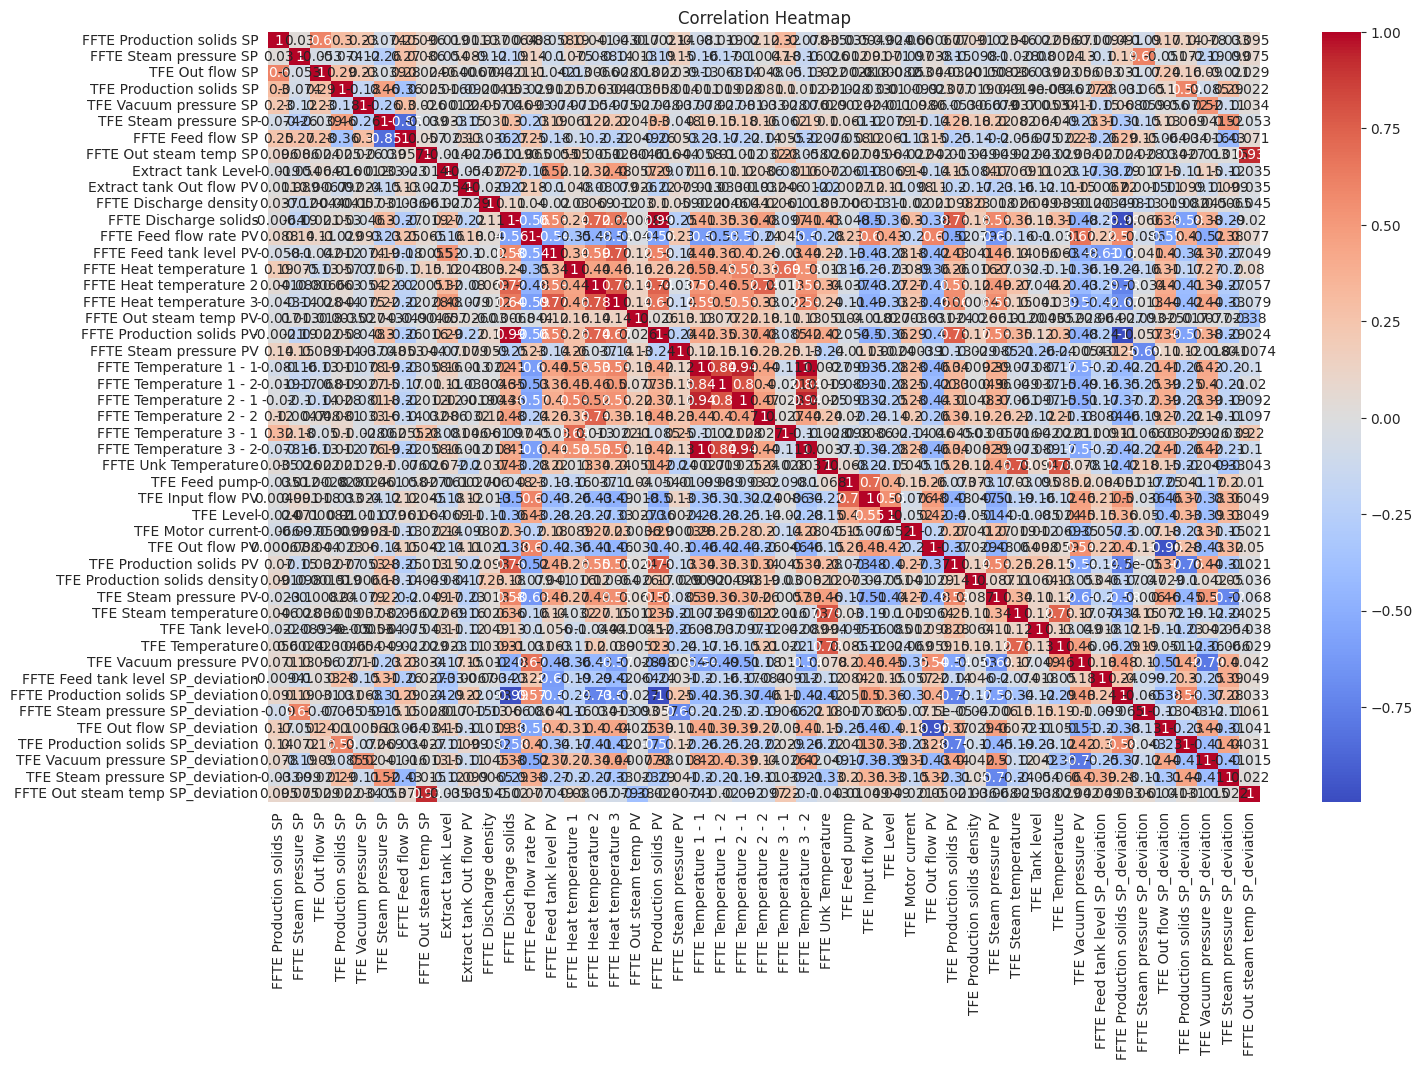

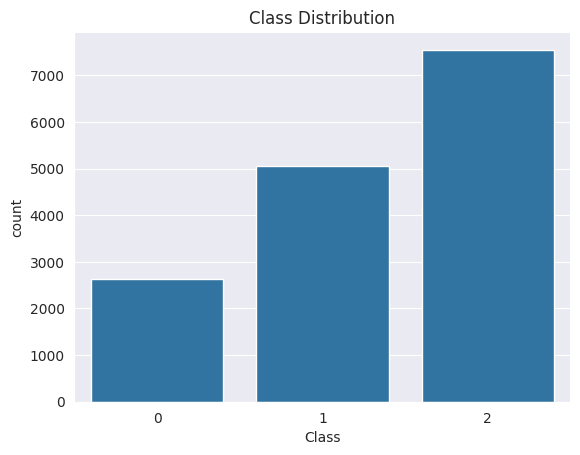

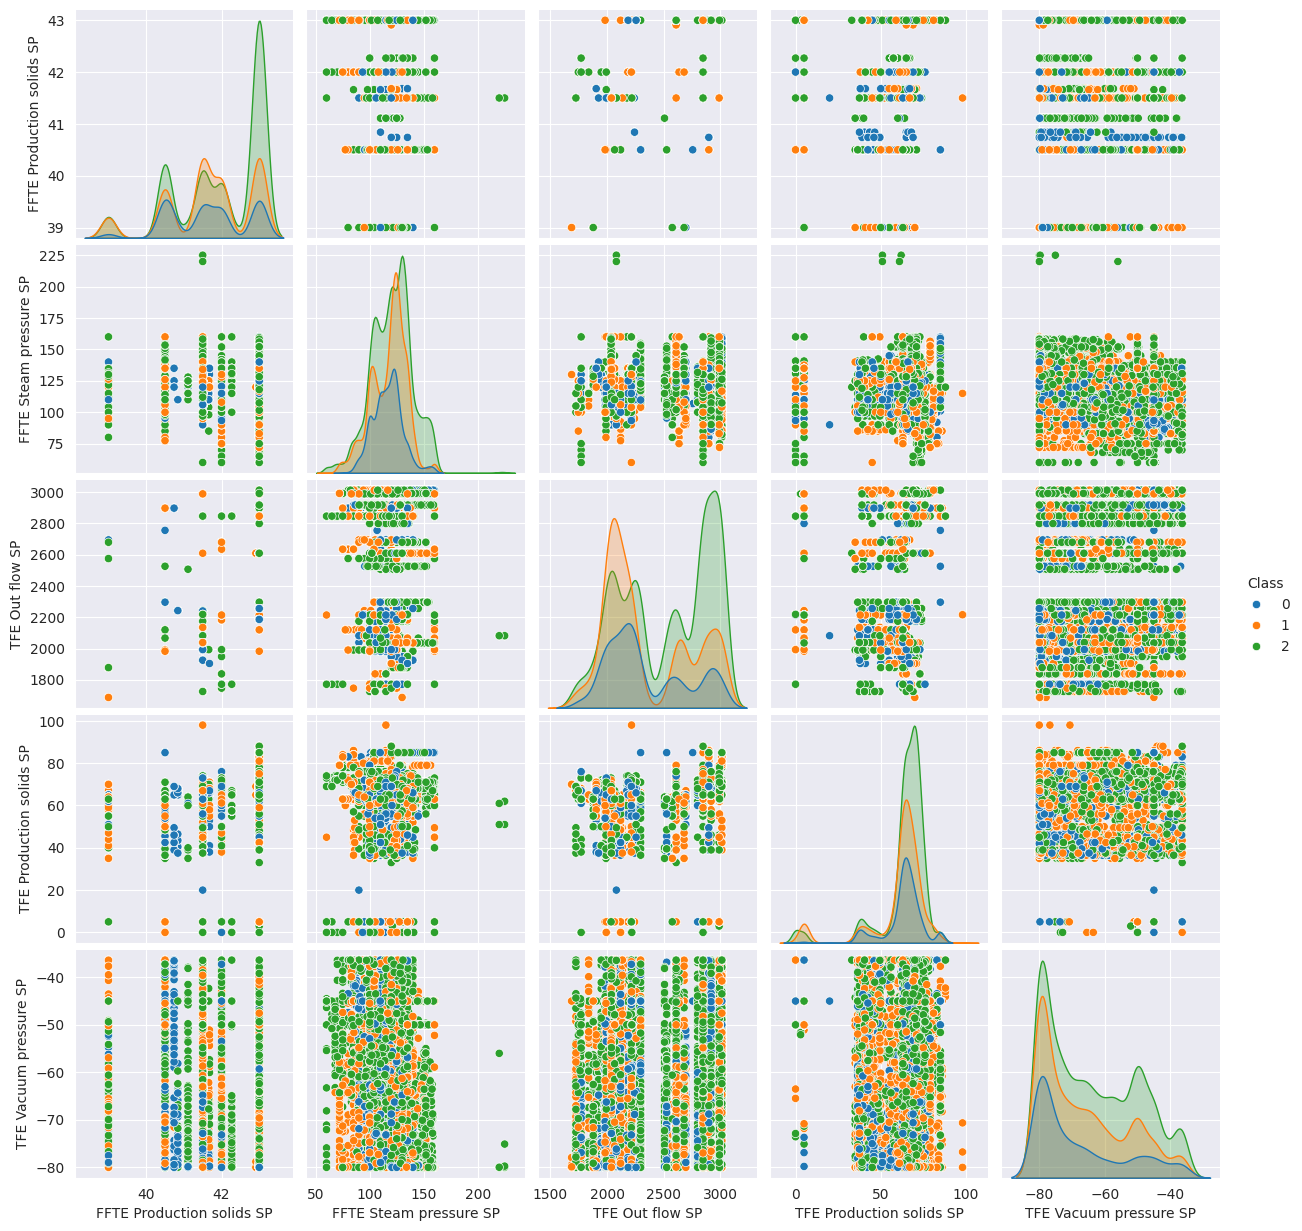

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show basic stats
print(train_df.describe(include='all'))

# Correlation heatmap (numeric features only)
plt.figure(figsize=(16, 10))
sns.heatmap(train_df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Visualize class distribution
sns.countplot(data=df, x='Class')
plt.title("Class Distribution")
plt.show()

# Pairplot of selected numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:5]  # pick top 5 for clarity
sns.pairplot(df[numeric_cols.tolist() + ['Class']], hue='Class')
plt.show()


In [47]:
# Example composite: ratio between two process variables
if 'Feed Flow PV' in df.columns and 'Feed Temp PV' in df.columns:
    df['Flow_Temp_Ratio'] = df['Feed Flow PV'] / (df['Feed Temp PV'] + 1e-5)  # prevent division by 0

# Example composite: difference between two settings
sp_cols = [col for col in df.columns if col.endswith("SP")]
pv_cols = [col for col in df.columns if col.endswith("PV")]

# Composite feature: deviation between SP and PV columns
for sp in sp_cols:
    match = sp.replace('SP', 'PV')
    if match in df.columns:
        # Convert both to float before subtraction to avoid TypeError
        df[f'{sp}_deviation'] = df[sp].astype(float) - df[match].astype(float)

# Check new columns added
new_cols = [col for col in df.columns if "deviation" in col or "Ratio" in col]
print("New columns created:\n", new_cols)



New columns created:
 ['FFTE Feed tank level SP_deviation', 'FFTE Production solids SP_deviation', 'FFTE Steam pressure SP_deviation', 'TFE Out flow SP_deviation', 'TFE Production solids SP_deviation', 'TFE Vacuum pressure SP_deviation', 'TFE Steam pressure SP_deviation', 'FFTE Out steam temp SP_deviation']


In [48]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Stratified sample of 1000 rows (~equal classes)
test_df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(n=333, random_state=1)).reset_index(drop=True)
train_df = df.drop(test_df.index).reset_index(drop=True)

# Feature-target split
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       333

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



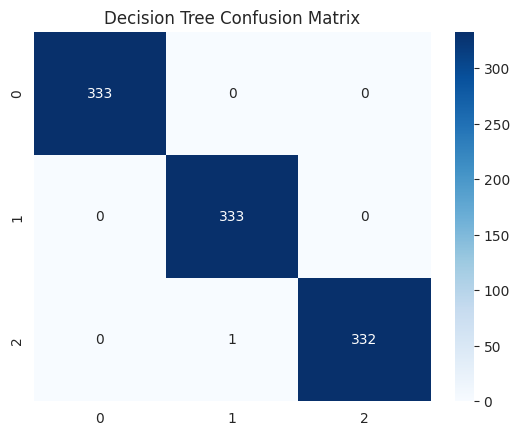

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       333

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



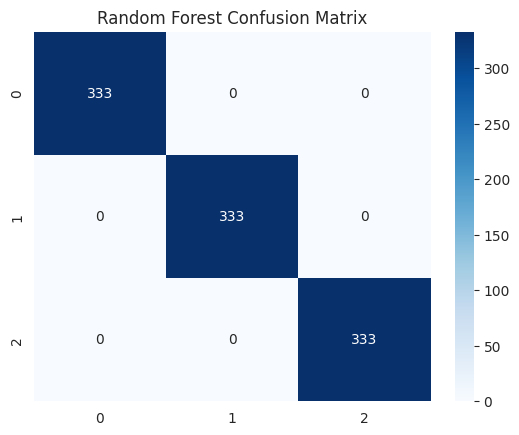

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.98      0.79      0.88       333
           1       0.88      0.87      0.88       333
           2       0.78      0.94      0.85       333

    accuracy                           0.87       999
   macro avg       0.88      0.87      0.87       999
weighted avg       0.88      0.87      0.87       999



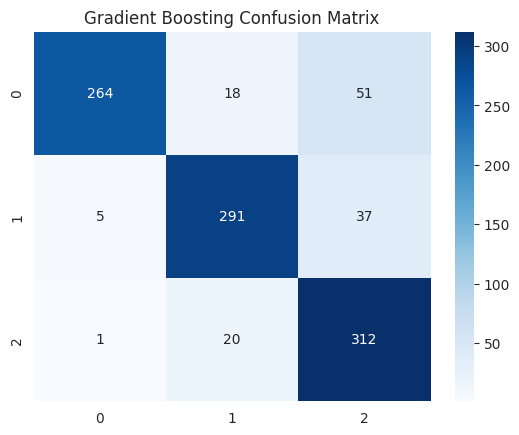

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.34      0.36      0.35       333
           2       0.42      0.82      0.56       333

    accuracy                           0.39       999
   macro avg       0.25      0.39      0.30       999
weighted avg       0.25      0.39      0.30       999



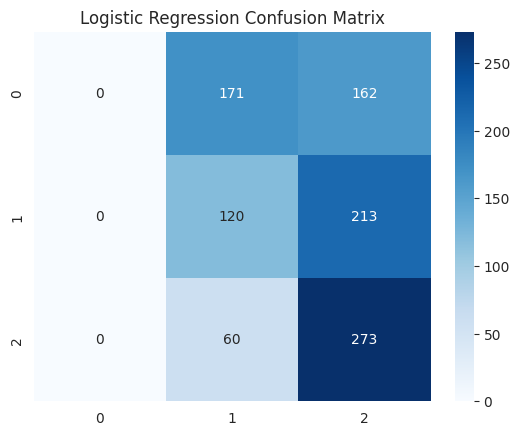

=== SVM ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.00      0.00      0.00       333
           2       0.33      1.00      0.50       333

    accuracy                           0.33       999
   macro avg       0.11      0.33      0.17       999
weighted avg       0.11      0.33      0.17       999



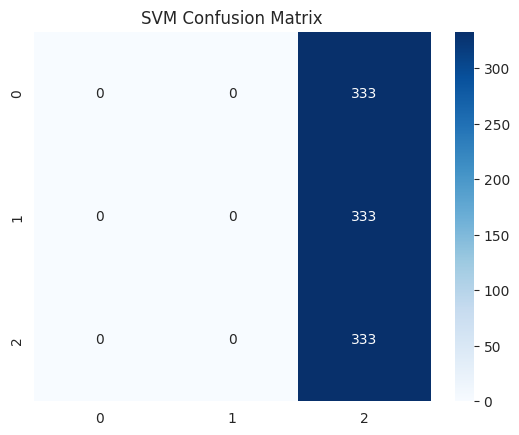

In [49]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Feature selection
selector = SelectKBest(f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Store selected feature names
selected_features = X_train.columns[selector.get_support()]

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500),
    'SVM': SVC(probability=True)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    preds = model.predict(X_test_selected)
    results[name] = {
        'model': model,
        'report': classification_report(y_test, preds, output_dict=True),
        'confusion_matrix': confusion_matrix(y_test, preds)
    }
    print(f"=== {name} ===")
    print(classification_report(y_test, preds))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()


In [50]:
comparison = pd.DataFrame({
    model: {
        'Precision': results[model]['report']['weighted avg']['precision'],
        'Recall': results[model]['report']['weighted avg']['recall'],
        'F1-score': results[model]['report']['weighted avg']['f1-score']
    }
    for model in results
}).T

comparison.sort_values(by='F1-score', ascending=False)


,Precision,Recall,F1-score
Random Forest,1.000000,1.000000,1.000000
Decision Tree,0.999002,0.998999,0.998999
Gradient Boosting,0.880759,0.867868,0.868691
Logistic Regression,0.254392,0.393393,0.302484
SVM,0.111111,0.333333,0.166667


In [51]:
import joblib

# Assuming Random Forest is best based on F1
best_model = results['Random Forest']['model']
joblib.dump(best_model, 'best_model.pkl')


['best_model.pkl']


--- Step 3 Continued: Evaluation of all models on 1000 unseen rows ---

=== Decision Tree on Unseen Data ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       333

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



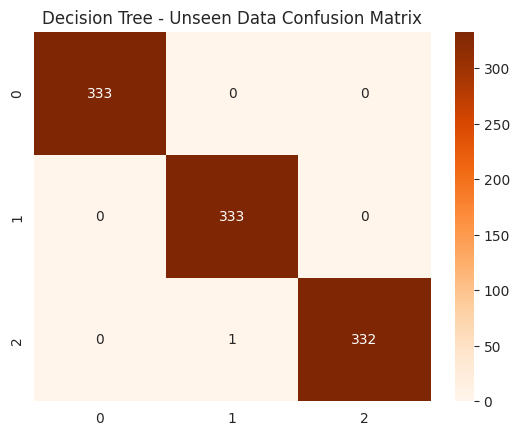


=== Random Forest on Unseen Data ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       333

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



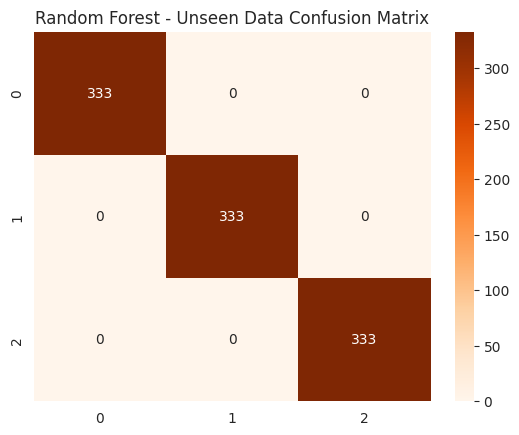


=== Gradient Boosting on Unseen Data ===
              precision    recall  f1-score   support

           0       0.98      0.79      0.88       333
           1       0.88      0.87      0.88       333
           2       0.78      0.94      0.85       333

    accuracy                           0.87       999
   macro avg       0.88      0.87      0.87       999
weighted avg       0.88      0.87      0.87       999



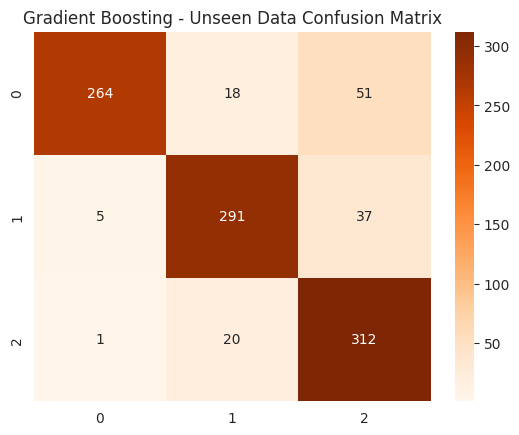


=== Logistic Regression on Unseen Data ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.34      0.36      0.35       333
           2       0.42      0.82      0.56       333

    accuracy                           0.39       999
   macro avg       0.25      0.39      0.30       999
weighted avg       0.25      0.39      0.30       999



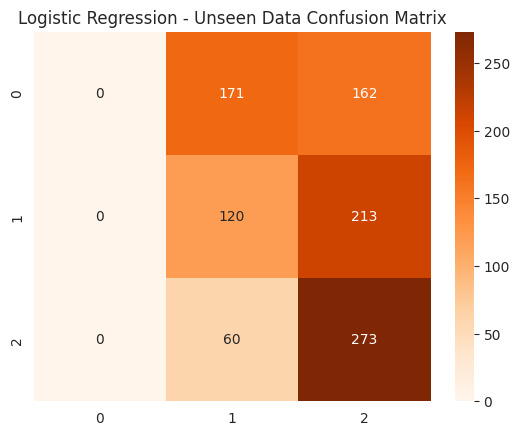


=== SVM on Unseen Data ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.00      0.00      0.00       333
           2       0.33      1.00      0.50       333

    accuracy                           0.33       999
   macro avg       0.11      0.33      0.17       999
weighted avg       0.11      0.33      0.17       999



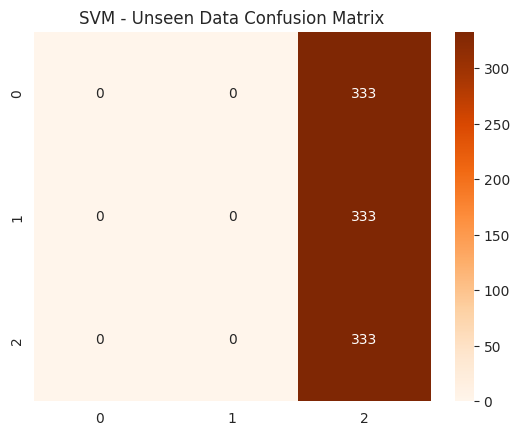


Model ranking on unseen data:
                      F1-score (unseen)
Random Forest                 1.000000
Decision Tree                 0.998999
Gradient Boosting             0.868691
Logistic Regression           0.302484
SVM                           0.166667


In [56]:
# Re-evaluate all models on the same X_unseen data
print("\n--- Step 3 Continued: Evaluation of all models on 1000 unseen rows ---")
model_ranks = {}

for name, model in results.items():
    preds_unseen = model['model'].predict(X_unseen)
    report = classification_report(y_test, preds_unseen, output_dict=True, zero_division=0)
    f1 = report['weighted avg']['f1-score']
    model_ranks[name] = f1
    print(f"\n=== {name} on Unseen Data ===")
    print(classification_report(y_test, preds_unseen))
    sns.heatmap(confusion_matrix(y_test, preds_unseen), annot=True, cmap='Oranges', fmt='d')
    plt.title(f"{name} - Unseen Data Confusion Matrix")
    plt.show()

# Final ranking on unseen data
ranking_df = pd.DataFrame.from_dict(model_ranks, orient='index', columns=['F1-score (unseen)'])
print("\nModel ranking on unseen data:\n", ranking_df.sort_values(by='F1-score (unseen)', ascending=False))


In [52]:
# Load the saved model
loaded_model = joblib.load('best_model.pkl')

# Transform test data again (selected features)
X_unseen = X_test[selected_features]

# Predict and evaluate
y_pred_unseen = loaded_model.predict(X_unseen)
print("Unseen data evaluation:")
print(classification_report(y_test, y_pred_unseen))


Unseen data evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       333
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       333

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



In [57]:
# Keep only SP columns + target variable
sp_cols_only = [col for col in df.columns if col.endswith('SP')]
sp_df = df[sp_cols_only + ['Class']].copy()

# Split again to match earlier logic
test_sp = sp_df.loc[test_df.index]
train_sp = sp_df.drop(test_sp.index)

X_sp = train_sp.drop(columns=['Class'])
y_sp = train_sp['Class']

# Train decision tree only on SPs
tree_sp = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_sp.fit(X_sp, y_sp)

# Show rules
from sklearn.tree import export_text

tree_rules = export_text(tree_sp, feature_names=list(X_sp.columns))
print("\n--- Step 4: Decision Tree Rules from SP Features ---\n")
print(tree_rules)



--- Step 4: Decision Tree Rules from SP Features ---

|--- TFE Out flow SP <= 2249.11
|   |--- FFTE Steam pressure SP <= 119.98
|   |   |--- TFE Out flow SP <= 2100.70
|   |   |   |--- TFE Vacuum pressure SP <= -67.99
|   |   |   |   |--- class: 1
|   |   |   |--- TFE Vacuum pressure SP >  -67.99
|   |   |   |   |--- class: 2
|   |   |--- TFE Out flow SP >  2100.70
|   |   |   |--- FFTE Feed flow SP <= 9215.00
|   |   |   |   |--- class: 2
|   |   |   |--- FFTE Feed flow SP >  9215.00
|   |   |   |   |--- class: 0
|   |--- FFTE Steam pressure SP >  119.98
|   |   |--- TFE Out flow SP <= 2036.03
|   |   |   |--- FFTE Steam pressure SP <= 143.55
|   |   |   |   |--- class: 2
|   |   |   |--- FFTE Steam pressure SP >  143.55
|   |   |   |   |--- class: 2
|   |   |--- TFE Out flow SP >  2036.03
|   |   |   |--- TFE Production solids SP <= 2.50
|   |   |   |   |--- class: 2
|   |   |   |--- TFE Production solids SP >  2.50
|   |   |   |   |--- class: 1
|--- TFE Out flow SP >  2249.11
|   |